# Methodological Classification Network Analysis

**Scoping Review:** *Building Standards for Agent-Based Models: A Proposal of Guidelines for Decision-Making on the Definition of Parameters and Sensitivity Analysis Methods.*

**Objective:** Analyze the co-occurrence patterns among methodological choices made by
researchers when designing ABMs — specifically the *data source for parameterization*,
*model objective*, and *sensitivity analysis method*. These three dimensions were classified
by domain experts for each included article.

**Methodology:** JBI / PRISMA-ScR | **Period:** 2015–2025 | **Databases:** SCOPUS, WoS, IEEE Xplore

---

## 0. Setup & Imports

In [1]:
import sys
import os
import warnings

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from src.methodological_network import (
    CATEGORY_DEFINITIONS,
    SHORT_LABELS,
    DIM_SHORT,
    DIM_COLORS,
    parse_classification_column,
    get_frequency,
    build_within_cooccurrence,
    build_network_from_edges,
    build_cross_column_edges,
    build_unified_methodological_network,
    compute_node_metrics,
    compute_global_metrics,
    plot_category_frequencies,
    plot_cross_heatmap,
    plot_within_network,
    plot_unified_network,
    plot_stacked_combinations,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})

FIG_DIR = os.path.join(PROJECT_ROOT, "notebooks", "figures_meth")
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures dir:  {FIG_DIR}")

Project root: c:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol
Figures dir:  c:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\notebooks\figures_meth


## 1. Data Loading

We load the same dataset from the scoping review. Three classification columns were coded
by domain experts during the data extraction phase (two blinded reviewers). Each article
can receive **multiple categories** per dimension (comma-separated), reflecting that many
ABMs combine more than one data source, objective, or sensitivity analysis approach.

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "ReviewArticlesCleanFinal.xlsx")
df = pd.read_excel(DATA_PATH, engine="openpyxl")

# Define the three classification columns
COLUMNS = [
    "Data Source (Parameterization)",
    "Model Objective (optional)",
    "Sensitivity Analysis",
]

print(f"Dataset: {df.shape[0]} articles × {df.shape[1]} columns")
print(f"\nClassification columns:")
for col in COLUMNS:
    n_filled = df[col].notna().sum()
    print(f"  {DIM_SHORT[col]:4s} | {col}: {n_filled}/{len(df)} ({n_filled/len(df):.1%} filled)")

Dataset: 348 articles × 10 columns

Classification columns:
  DS   | Data Source (Parameterization): 304/348 (87.4% filled)
  MO   | Model Objective (optional): 304/348 (87.4% filled)
  SA   | Sensitivity Analysis: 283/348 (81.3% filled)


## 2. Exploratory Data Analysis

### Theoretical Foundation

The three classification dimensions capture distinct facets of the ABM design process:

- **Data Source (DS):** How the model's parameters were grounded — from pure theory,
  empirical data (micro or macro level), expert knowledge, hybrid approaches, or
  synthetic/AI-generated data. This reflects the epistemological basis of the model.

- **Model Objective (MO):** The intended purpose of the simulation — exploration of
  emergent phenomena, explanation of causal mechanisms, prediction of future states,
  policy evaluation, or educational illustration.

- **Sensitivity Analysis (SA):** The method used to assess how parameter uncertainty
  propagates through the model — from simple one-at-a-time (OAT) approaches to
  variance-based global methods (e.g., Sobol indices), metamodeling, or scenario-based
  exploration. Articles reporting no sensitivity analysis are coded as "NA".

Each article can belong to **multiple categories** within each dimension, since real-world
ABM designs often combine approaches (e.g., theory + empirical data; exploratory +
policy evaluation). This multi-label nature makes co-occurrence analysis informative.

### 2.1 Parse Classification Columns

Each multi-value cell (e.g., `"Theoretical (literature), Empirical (macro)"`) is split
into a list of individual categories.

In [3]:
import re

def smart_parse(text: str) -> list[str]:
    """
    Split multi-value classification string on ';' only at the top level
    (i.e. not inside parentheses or quotes). Also strips surrounding quotes.
    """
    result = []
    depth = 0
    current = []
    
    for char in text:
        if char == '(':
            depth += 1
            current.append(char)
        elif char == ')':
            depth -= 1
            current.append(char)
        elif char == ';' and depth == 0:
            item = ''.join(current).strip().strip('"')
            if item:
                result.append(item)
            current = []
        else:
            current.append(char)
    
    # flush last token
    item = ''.join(current).strip().strip('"')
    if item:
        result.append(item)
    
    return result


parsed = {}
for col in COLUMNS:
    parsed[col] = df[col].dropna().astype(str).apply(smart_parse)
    
    n_multi = (parsed[col].apply(len) > 1).sum()
    n_non_null = df[col].notna().sum()
    
    if n_non_null > 0:
        print(f"{DIM_SHORT[col]:4s} | Multi-label articles: {n_multi} "
              f"({n_multi/n_non_null:.1%} of non-null)")
    else:
        print(f"{DIM_SHORT[col]:4s} | No data found in this column.")

DS   | Multi-label articles: 62 (20.4% of non-null)
MO   | Multi-label articles: 115 (37.8% of non-null)
SA   | Multi-label articles: 108 (38.2% of non-null)


### 2.2 Category Frequency Distribution

Understanding how frequently each category appears reveals the dominant methodological
choices in the literature. Imbalanced distributions (e.g., most articles using theoretical
data sources) highlight potential gaps and underexplored approaches.

In [4]:
# Compute frequencies
freq_dict = {}
for col in COLUMNS:
    freq_dict[col] = get_frequency(parsed[col])
    dim = DIM_SHORT[col]
    print(f"\n{'='*50}")
    print(f"{dim}: {col}")
    print(f"{'='*50}")
    for cat, count in freq_dict[col].items():
        pct = count / df[col].notna().sum() * 100
        bar = '█' * int(pct / 2)
        print(f"  {SHORT_LABELS.get(cat, cat):22s} {count:4d} ({pct:5.1f}%) {bar}")


DS: Data Source (Parameterization)
  Hybrid                  151 ( 49.7%) ████████████████████████
  Emp. Micro               88 ( 28.9%) ██████████████
  Theoretical              66 ( 21.7%) ██████████
  Emp. Macro               36 ( 11.8%) █████
  Synthetic (machine learning and AI)   24 (  7.9%) ███
  Expert-based             10 (  3.3%) █

MO: Model Objective (optional)
  Decision Support        162 ( 53.3%) ██████████████████████████
  Explanatory              84 ( 27.6%) █████████████
  Exploratory              57 ( 18.8%) █████████
  Theoretical/Illust.      55 ( 18.1%) █████████
  Predictive               40 ( 13.2%) ██████
  Descriptive              20 (  6.6%) ███
  Communication             2 (  0.7%) 

SA: Sensitivity Analysis
  Scenario-based          195 ( 68.9%) ██████████████████████████████████
  Local (OAT)              79 ( 27.9%) █████████████
  Regression/Stat.         73 ( 25.8%) ████████████
  Global (Variance)        25 (  8.8%) ████
  Metamodeling             

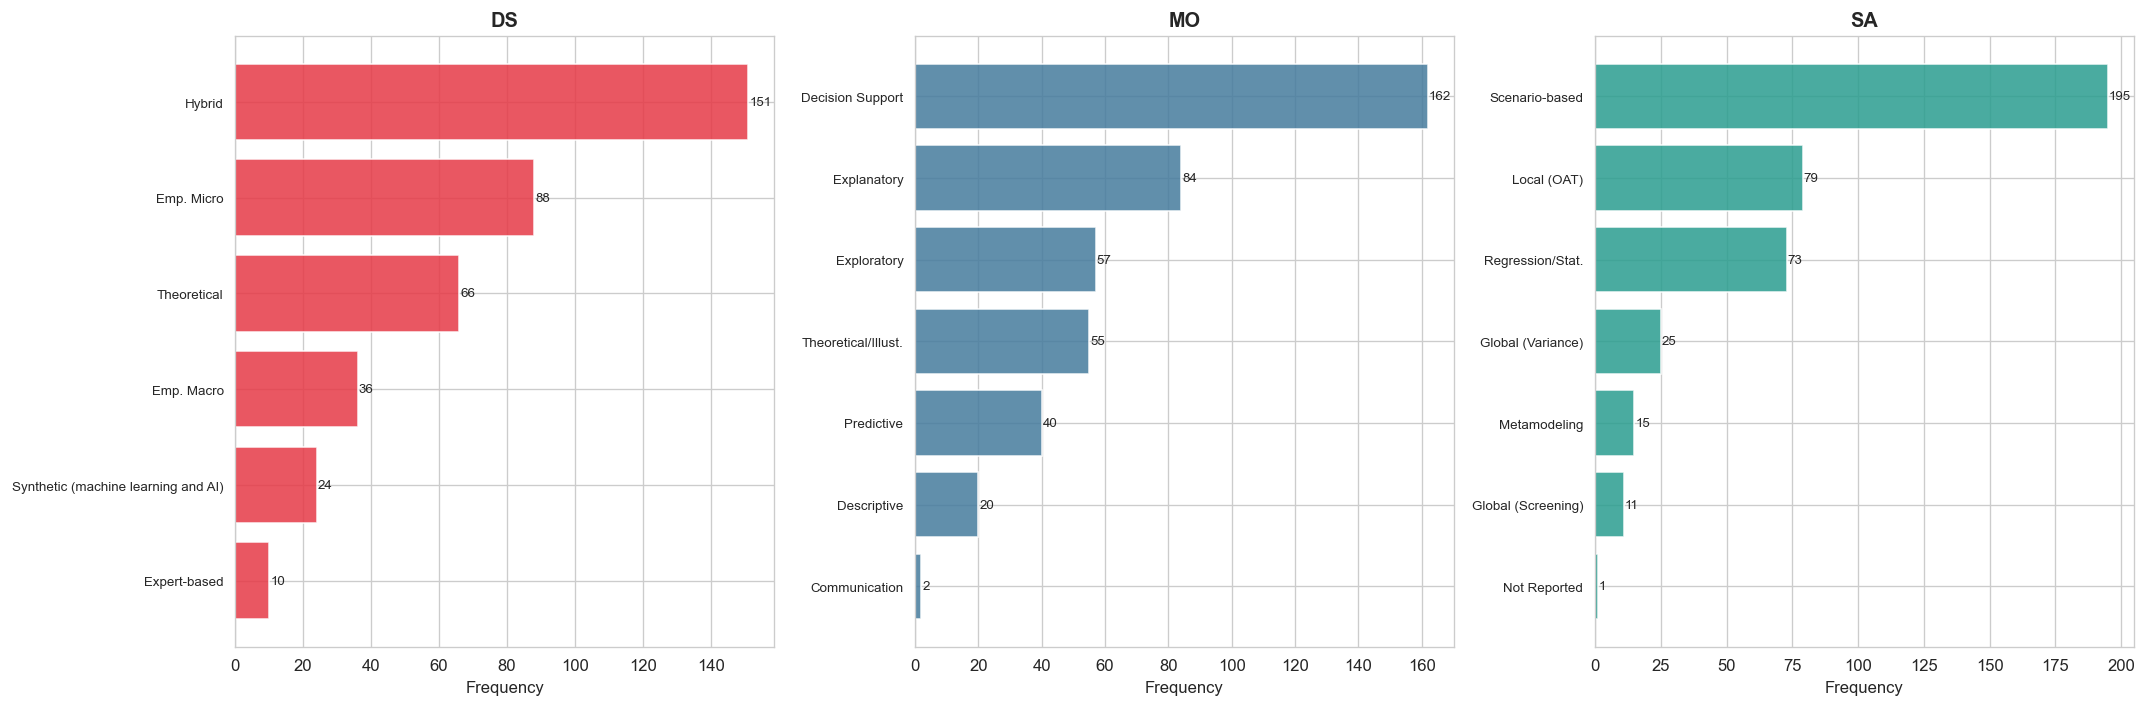

In [5]:
fig_freq = plot_category_frequencies(
    freq_dict, figsize=(18, 6),
    save_path=os.path.join(FIG_DIR, "category_frequencies.png")
)
plt.show()

### 2.3 Multi-label Statistics

How many categories does each article receive? Articles with multiple categories per
dimension indicate methodological pluralism — the researcher combined multiple approaches.
The distribution of category counts per article characterizes the degree of methodological
hybridization in the field.

In [6]:
for col in COLUMNS:
    counts = parsed[col].apply(len)
    counts_nz = counts[counts > 0]
    dim = DIM_SHORT[col]
    print(f"{dim}: mean={counts_nz.mean():.2f}, median={counts_nz.median():.0f}, "
          f"max={counts_nz.max()}, single-label={( counts_nz == 1).sum()}, "
          f"multi-label={(counts_nz > 1).sum()}")

DS: mean=1.23, median=1, max=3, single-label=242, multi-label=62
MO: mean=1.38, median=1, max=3, single-label=189, multi-label=115
SA: mean=1.41, median=1, max=4, single-label=175, multi-label=108


## 3. Within-Dimension Co-occurrence Networks

### Theoretical Foundation

A **within-dimension co-occurrence network** captures how categories *within the same
classification dimension* are combined in individual articles. For example, in the
Data Source dimension, an edge between *Theoretical* and *Empirical (macro)* means that
some articles used both literature-based and macro-empirical data for parameterization.

Formally, for dimension $D$ with categories $\{c_1, c_2, \ldots, c_k\}$, the network
$G_D = (V_D, E_D, w_D)$ is defined as:
- $V_D$ = set of categories in $D$
- $E_D = \{(c_i, c_j) : \exists$ article with both $c_i$ and $c_j\}$
- $w_D(c_i, c_j)$ = number of articles containing both categories

These networks reveal which methodological choices are **complementary** (frequently combined)
versus **substitutive** (rarely or never combined). Strong edges indicate common hybrid
practices in ABM design.

**Note:** Within-dimension networks are typically small (6–7 nodes), so visual inspection
and edge weights are more informative than complex centrality metrics.

In [7]:
# Build and visualize within-dimension networks
within_networks = {}
within_metrics = {}

for col in COLUMNS:
    dim = DIM_SHORT[col]
    print(f"\n{'='*60}")
    print(f"WITHIN-DIMENSION NETWORK: {dim} ({col})")
    print(f"{'='*60}")

    # Build edges
    edge_df = build_within_cooccurrence(parsed[col], min_weight=1)
    G = build_network_from_edges(edge_df)
    within_networks[col] = G

    if G.number_of_nodes() > 0:
        print(f"  Nodes: {G.number_of_nodes()}")
        print(f"  Edges: {G.number_of_edges()}")
        print(f"  Density: {nx.density(G):.4f}")
        print(f"\n  Edge list:")
        for _, row in edge_df.sort_values('weight', ascending=False).iterrows():
            a = SHORT_LABELS.get(row['source'], row['source'])
            b = SHORT_LABELS.get(row['target'], row['target'])
            print(f"    {a:25s} <-> {b:25s}  w={row['weight']}")

        within_metrics[col] = compute_node_metrics(G)
    else:
        print("  No co-occurrences found (all articles single-label).")


WITHIN-DIMENSION NETWORK: DS (Data Source (Parameterization))
  Nodes: 6
  Edges: 13
  Density: 0.8667

  Edge list:
    Emp. Micro                <-> Hybrid                     w=21
    Emp. Macro                <-> Emp. Micro                 w=12
    Synthetic (machine learning and AI) <-> Theoretical                w=9
    Emp. Macro                <-> Synthetic (machine learning and AI)  w=7
    Expert-based              <-> Hybrid                     w=6
    Emp. Micro                <-> Synthetic (machine learning and AI)  w=6
    Emp. Micro                <-> Expert-based               w=5
    Emp. Macro                <-> Hybrid                     w=4
    Emp. Macro                <-> Theoretical                w=3
    Hybrid                    <-> Synthetic (machine learning and AI)  w=3
    Emp. Micro                <-> Theoretical                w=2
    Expert-based              <-> Theoretical                w=1
    Emp. Macro                <-> Expert-based              

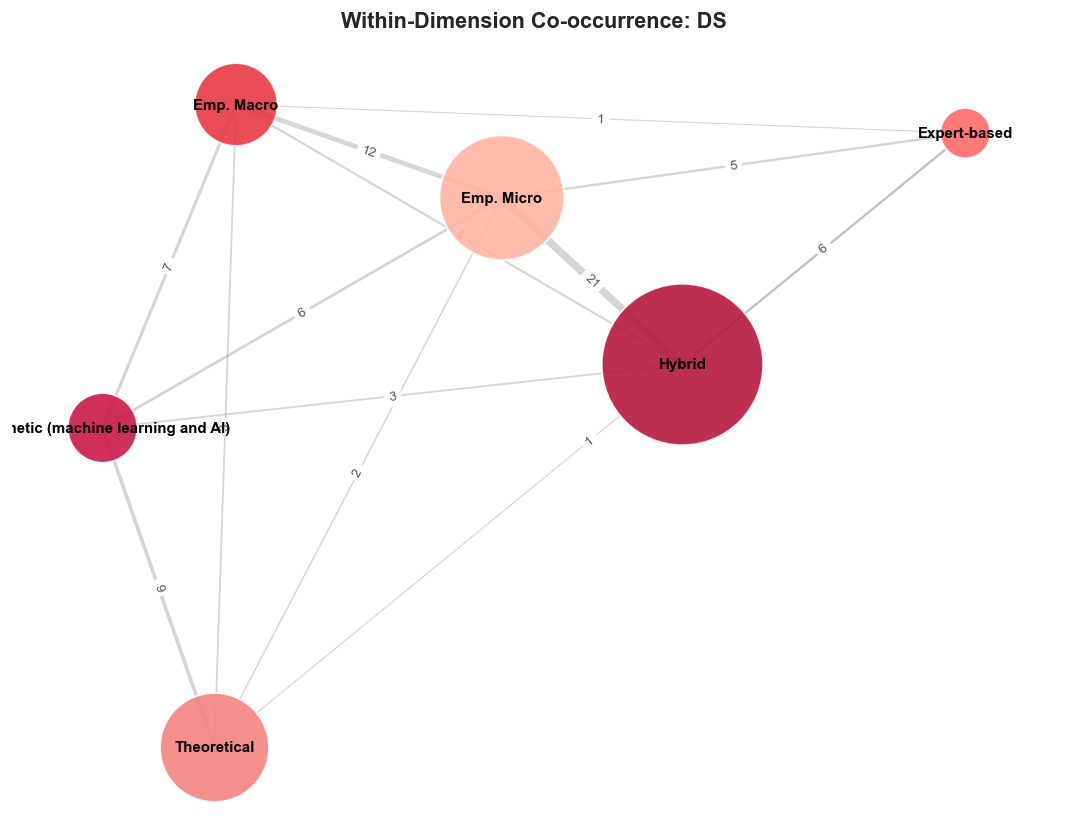

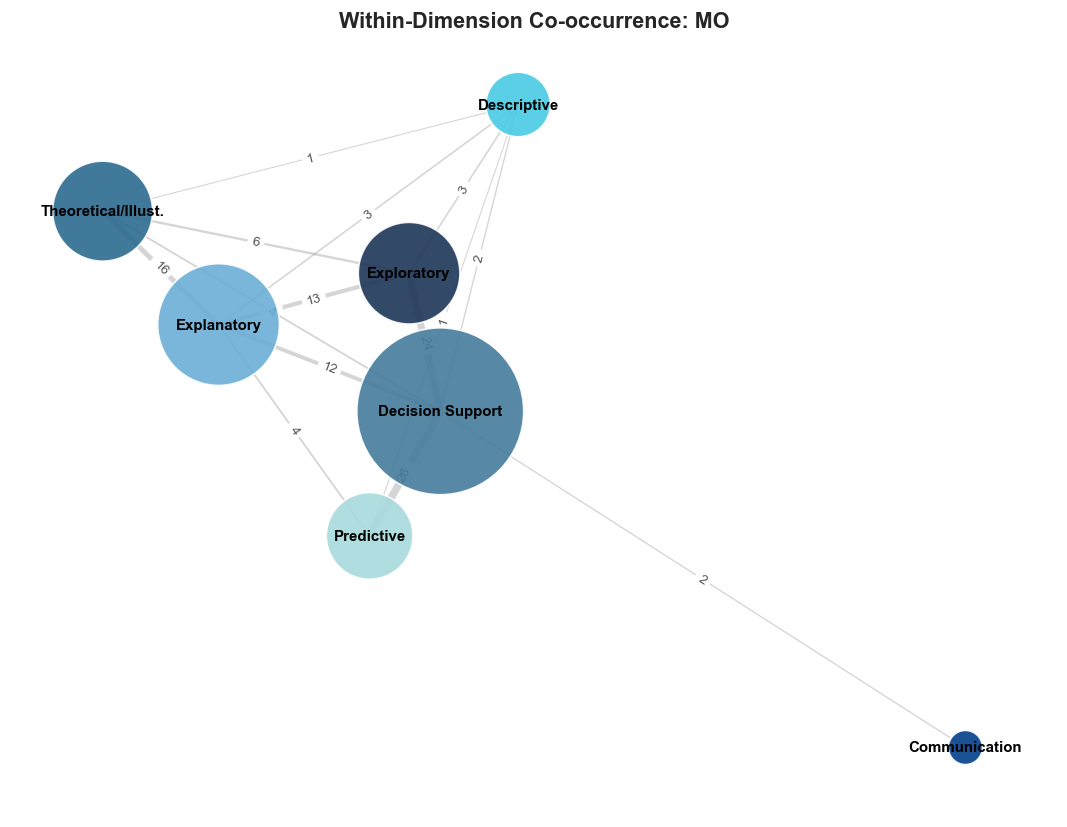

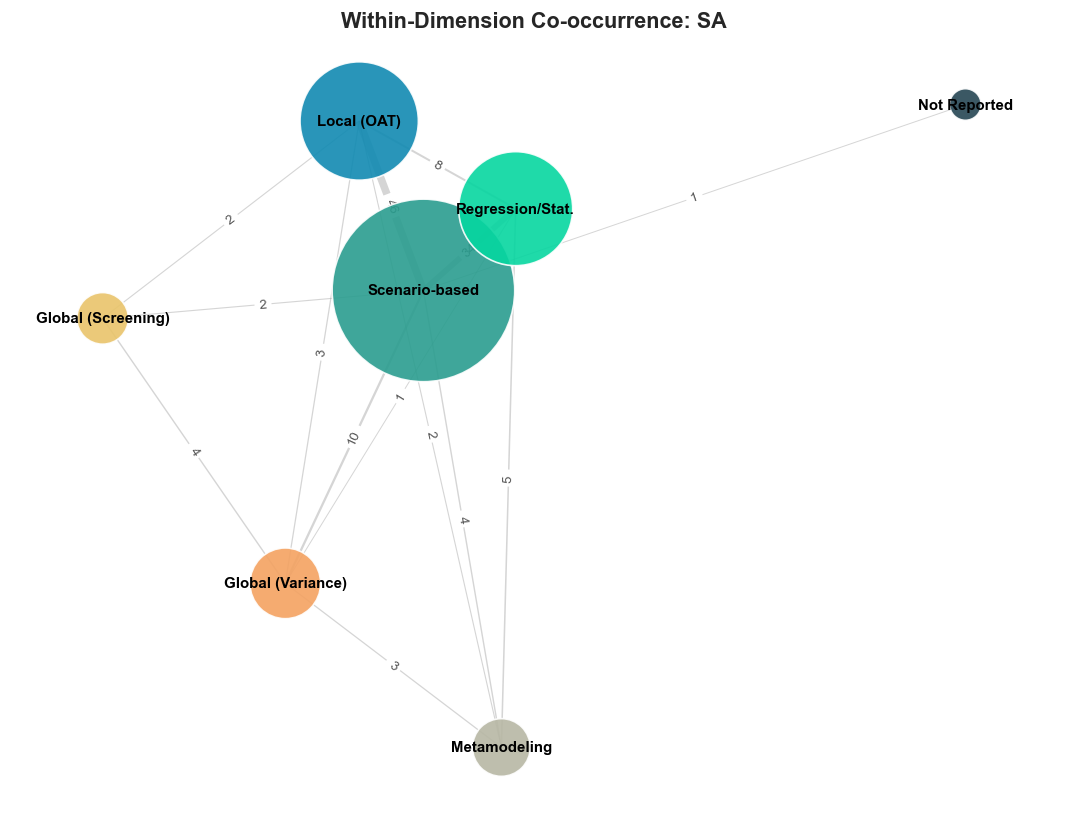

In [8]:
# --- Visualize each within-dimension network ---
for col in COLUMNS:
    dim = DIM_SHORT[col]
    G = within_networks[col]
    if G.number_of_nodes() > 0:
        fig = plot_within_network(
            G, col, freq_dict[col],
            figsize=(9, 7),
            save_path=os.path.join(FIG_DIR, f"within_network_{dim}.png"),
        )
        plt.show()
    else:
        print(f"  {dim}: No co-occurrence network to display.")

## 4. Cross-Dimension Co-occurrence Analysis

### Theoretical Foundation

While within-dimension networks show which approaches are combined *within the same facet*,
**cross-dimension analysis** reveals how choices in one dimension relate to choices in another.

For example:
- Do articles using *empirical micro data* tend to perform *variance-based global sensitivity analysis*?
- Are *exploratory models* more likely to use *theoretical parameterization*?
- Is *no sensitivity analysis* (NA) associated with particular model objectives?

These patterns expose the **methodological profiles** of the field — the typical and atypical
combinations of design choices. Cross-tabulation heatmaps provide a direct visual answer.

Formally, for dimensions $D_A$ and $D_B$, the cross-occurrence matrix $M$ is:
$$M_{ij} = |\{\text{articles containing } c_i \in D_A \text{ AND } c_j \in D_B\}|$$

### 4.1 Data Source × Model Objective

This heatmap reveals how the epistemological grounding of the model (data source)
relates to its intended purpose (objective). Strong cells indicate dominant methodological
archetypes; empty cells indicate unexplored combinations.

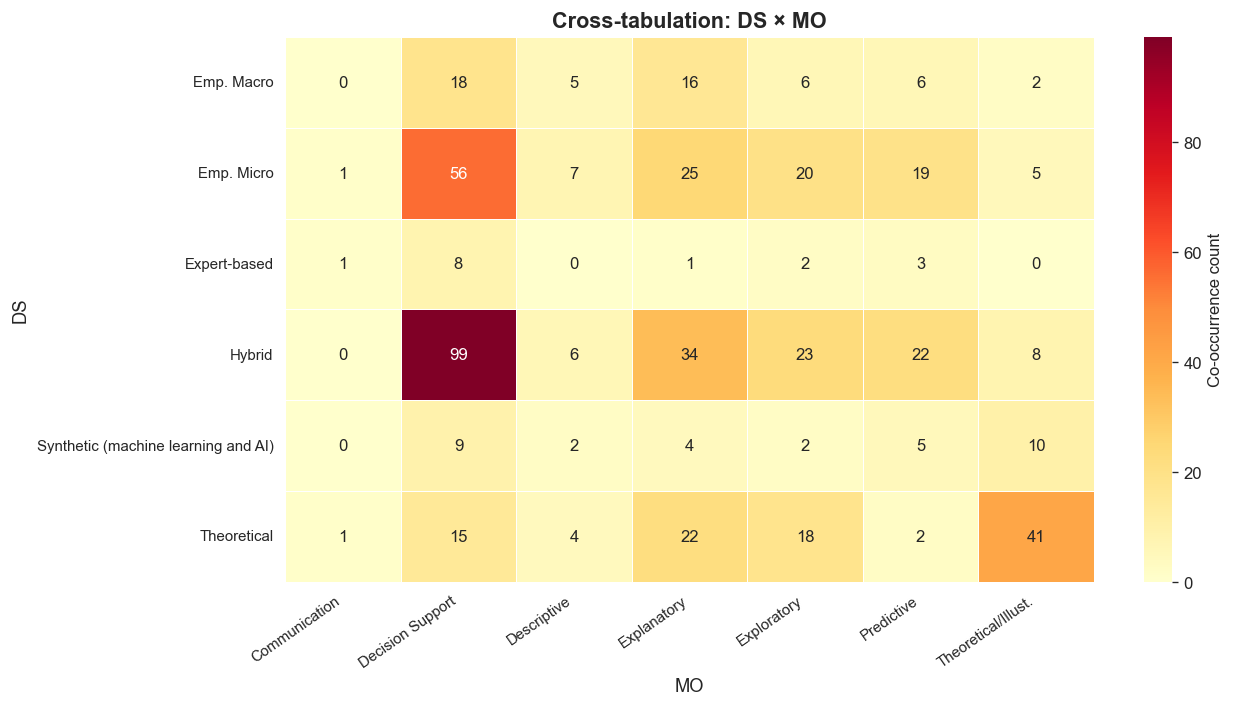

In [9]:
fig_hm1 = plot_cross_heatmap(
    parsed[COLUMNS[0]], parsed[COLUMNS[1]],
    COLUMNS[0], COLUMNS[1],
    figsize=(11, 6),
    save_path=os.path.join(FIG_DIR, "heatmap_DS_x_MO.png"),
)
plt.show()

### 4.2 Data Source × Sensitivity Analysis

This heatmap shows whether the rigor of sensitivity analysis varies with the data source.
A hypothesis to explore: models grounded in empirical data may undergo more rigorous
sensitivity testing than purely theoretical models.

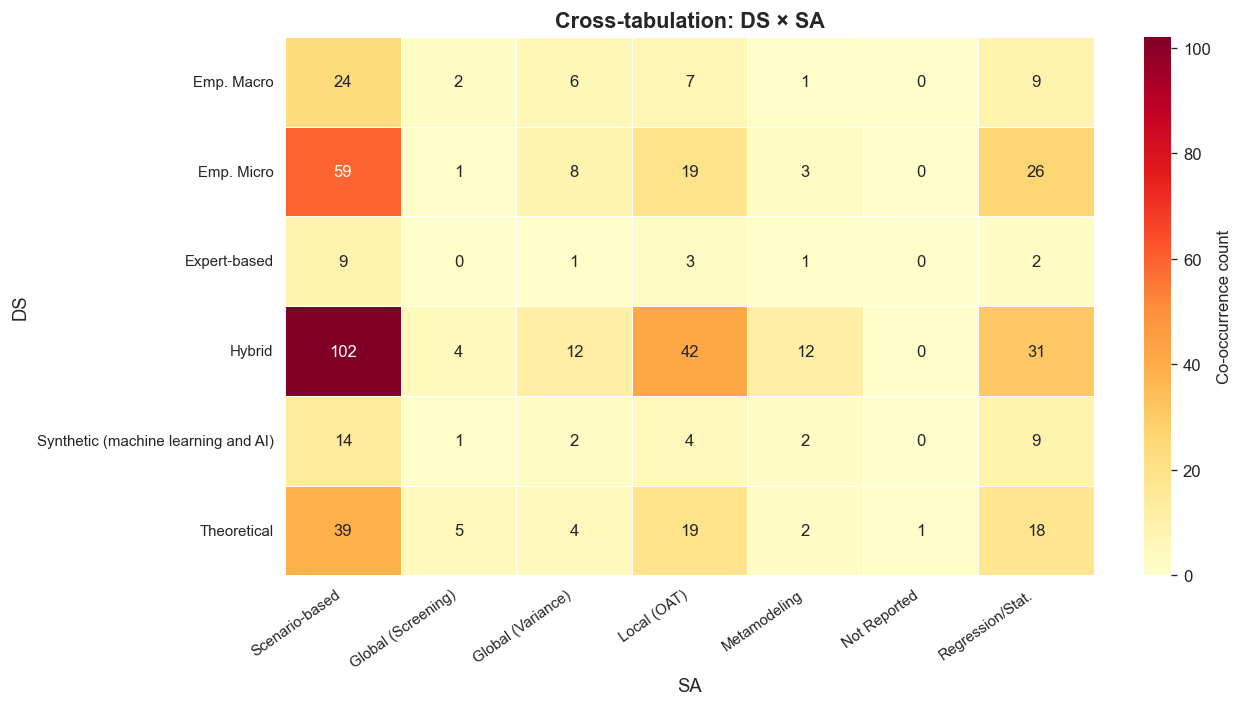

In [10]:
fig_hm2 = plot_cross_heatmap(
    parsed[COLUMNS[0]], parsed[COLUMNS[2]],
    COLUMNS[0], COLUMNS[2],
    figsize=(11, 6),
    save_path=os.path.join(FIG_DIR, "heatmap_DS_x_SA.png"),
)
plt.show()

### 4.3 Model Objective × Sensitivity Analysis

This heatmap explores whether certain model objectives are associated with specific
sensitivity analysis methods. Predictive models, for instance, may require more
comprehensive sensitivity analysis than exploratory or illustrative models.

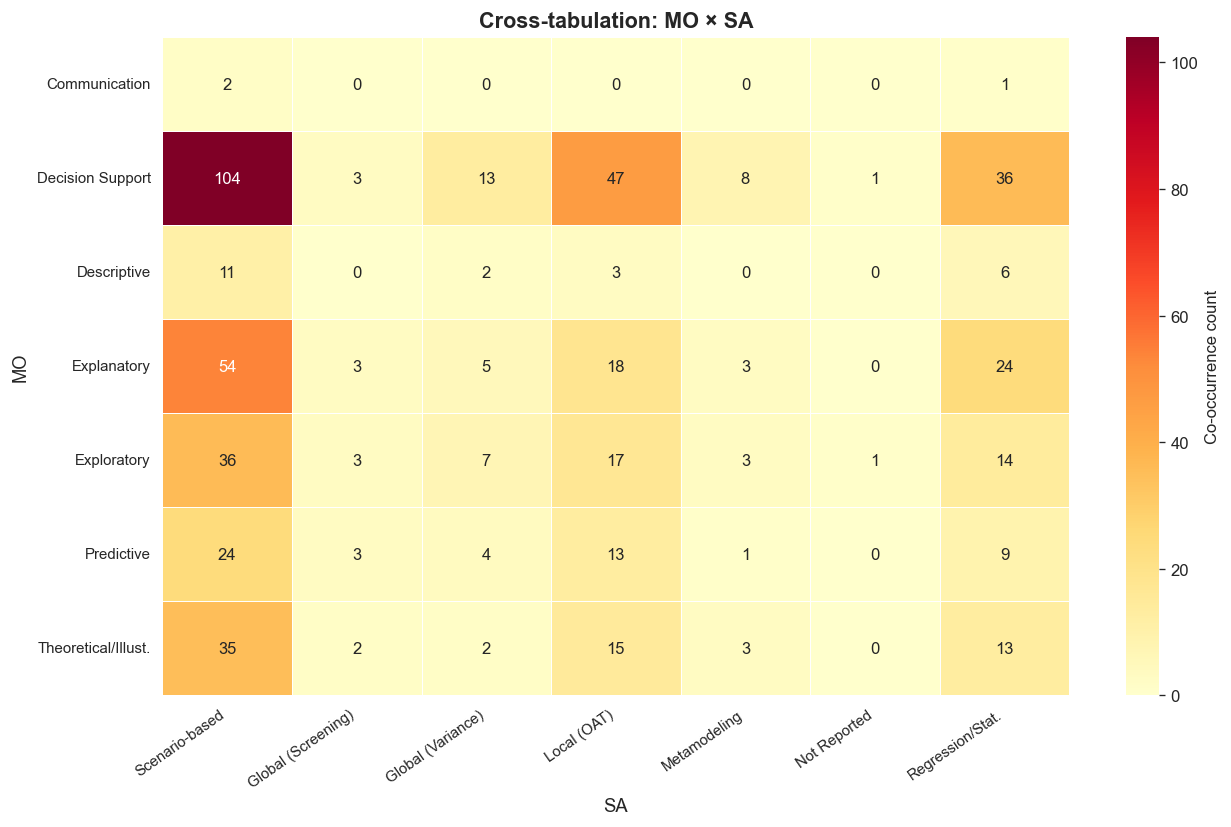

In [11]:
fig_hm3 = plot_cross_heatmap(
    parsed[COLUMNS[1]], parsed[COLUMNS[2]],
    COLUMNS[1], COLUMNS[2],
    figsize=(11, 7),
    save_path=os.path.join(FIG_DIR, "heatmap_MO_x_SA.png"),
)
plt.show()

## 5. Unified Methodological Network

### Theoretical Foundation

The **unified methodological network** integrates all three classification dimensions
into a single graph, combining both within-dimension and cross-dimension co-occurrence edges.

This network $G_U = (V_U, E_U, w_U)$ is constructed as follows:
- $V_U = V_{DS} \cup V_{MO} \cup V_{SA}$ — nodes from all three dimensions
- Within-dimension edges: $(c_i, c_j)$ where both belong to the same dimension and
  co-occur in at least one article
- Cross-dimension edges: $(c_i, c_j)$ where $c_i \in D_A$, $c_j \in D_B$ ($A \neq B$)
  and both co-occur in at least one article

The resulting graph reveals the **holistic methodological landscape**: which design
choices cluster together across all dimensions. Centrality analysis on this network
identifies the most structurally important methodological choices.

**Visual encoding:**
- Node **color** = dimension (red = Data Source, blue = Model Objective, teal = Sensitivity Analysis)
- Node **size** = weighted degree (structural importance)
- **Solid edges** = within-dimension co-occurrence
- **Dashed edges** = cross-dimension co-occurrence
- **Edge thickness** = co-occurrence weight

In [12]:
# --- 5.1 Build unified network ---
G_unified = build_unified_methodological_network(
    parsed,
    min_weight_within=1,
    min_weight_cross=2,  # Filter cross-dim noise
)

print(f"Unified Methodological Network:")
print(f"  Nodes: {G_unified.number_of_nodes()}")
print(f"  Edges: {G_unified.number_of_edges()}")
print(f"  Density: {nx.density(G_unified):.4f}")

# Node count per dimension
dims = nx.get_node_attributes(G_unified, 'dimension')
from collections import Counter
dim_counts = Counter(dims.values())
print(f"\n  Nodes per dimension:")
for d, c in sorted(dim_counts.items(), key=lambda x: -x[1]):
    print(f"    {DIM_SHORT.get(d, d):4s}: {c}")

Unified Methodological Network:
  Nodes: 20
  Edges: 138
  Density: 0.7263

  Nodes per dimension:
    MO  : 7
    SA  : 7
    DS  : 6


In [13]:
# --- 5.2 Compute metrics ---
unified_metrics = compute_node_metrics(G_unified)
unified_global = compute_global_metrics(G_unified)

print("GLOBAL METRICS — Unified Methodological Network")
print("=" * 55)
for k, v in unified_global.items():
    if isinstance(v, float):
        print(f"  {k:35s} {v:.4f}")
    else:
        print(f"  {k:35s} {v}")

print(f"\nNODE METRICS (all categories ranked by weighted degree):")
unified_metrics[["weighted_degree", "betweenness_centrality",
                 "closeness_centrality", "eigenvector_centrality", "dimension"]]

GLOBAL METRICS — Unified Methodological Network
  nodes                               20
  edges                               138
  density                             0.7263
  avg_degree                          13.8000
  avg_weighted_degree                 188.9000
  connected_components                1
  avg_clustering                      0.0854
  diameter                            2
  avg_shortest_path                   1.2737

NODE METRICS (all categories ranked by weighted degree):


,weighted_degree,betweenness_centrality,closeness_centrality,eigenvector_centrality,dimension
category,,,,,
Exploratory / Scenario-based,610,0.149123,1.000000,0.500998,Sensitivity Analysis
Decision Support / Policy Evaluation,486,0.049708,0.950000,0.450367,Model Objective (optional)
Hybrid,429,0.000000,0.863636,0.421454,Data Source (Parameterization)
Empirical (micro),293,0.000000,0.863636,0.275779,Data Source (Parameterization)
Local (OAT/OFAT),268,0.005848,0.904762,0.258429,Sensitivity Analysis
Explanatory,256,0.000000,0.863636,0.228680,Model Objective (optional)
Regression / Statistical Inference,245,0.013645,0.863636,0.219039,Sensitivity Analysis
Theoretical (literature),204,0.085283,0.863636,0.157046,Data Source (Parameterization)
Exploratory,197,0.011696,0.863636,0.182826,Model Objective (optional)


### 5.3 Centrality Interpretation

In the unified methodological network, centrality metrics have specific interpretations:

- **Weighted degree**: A category with high weighted degree is frequently combined with
  many other methodological choices. It represents a **versatile** or **dominant** approach.

- **Betweenness centrality**: A category with high betweenness lies on the shortest paths
  between many other categories. It serves as a **methodological bridge** — connecting
  different design philosophies. Removing this category would fragment the network.

- **Closeness centrality**: A category with high closeness can "reach" all other
  methodological choices quickly — it is central to the methodological discourse.

- **Eigenvector centrality**: A category with high eigenvector centrality is connected
  to other highly connected categories — it belongs to the "core" methodological cluster.

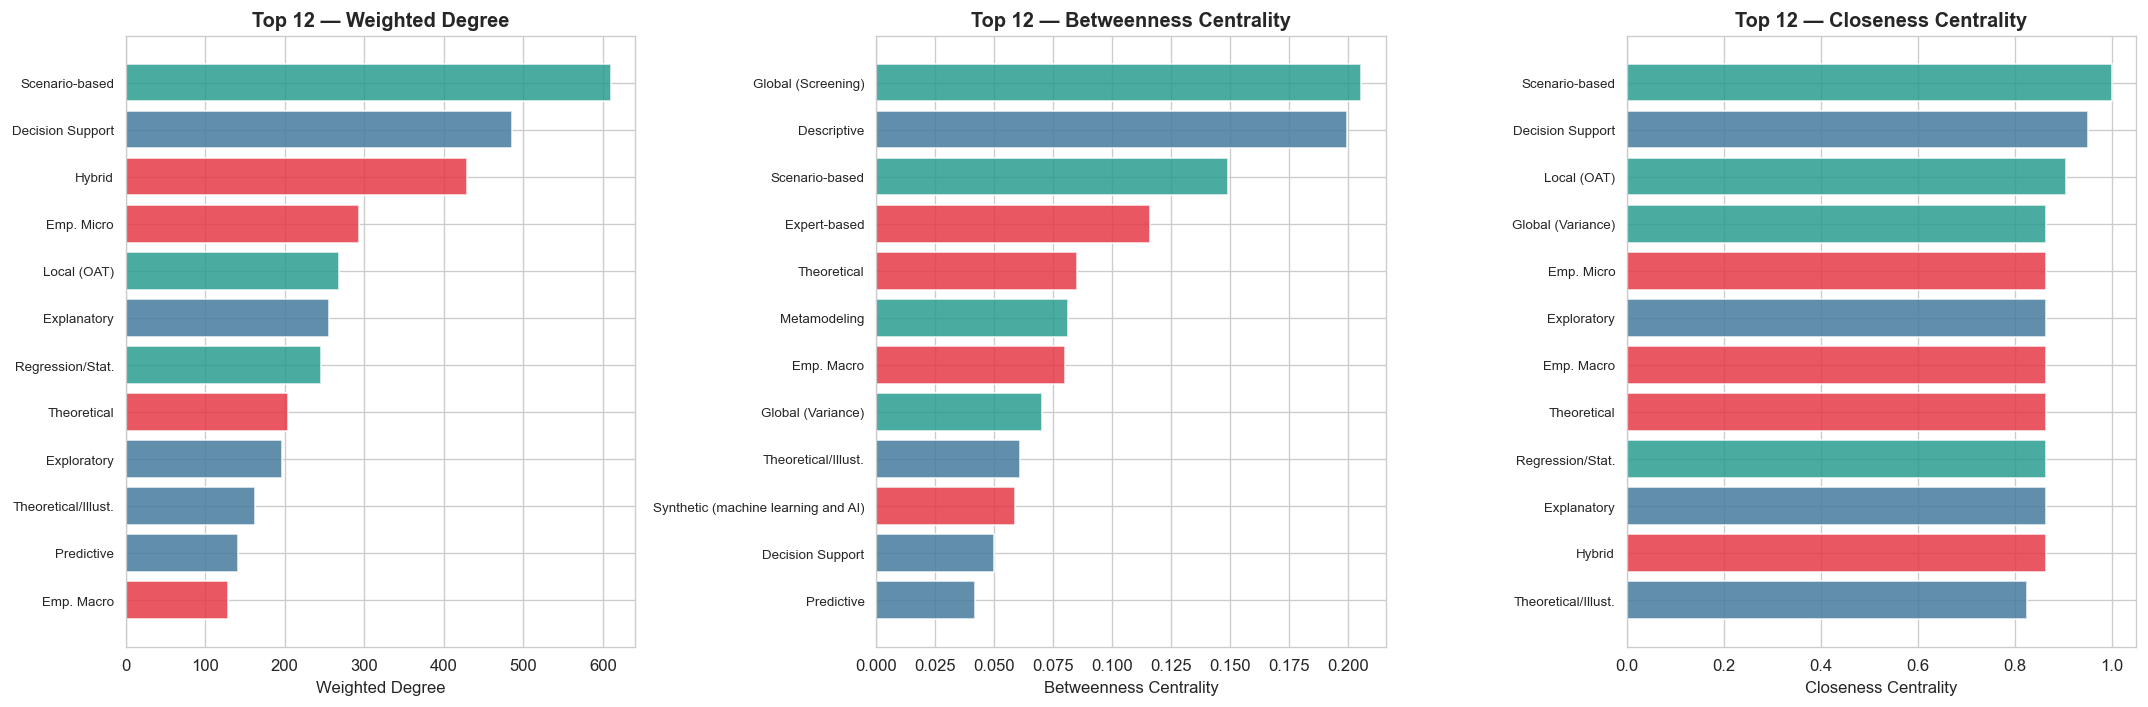

In [14]:
# --- 5.4 Top categories by centrality (bar chart) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="white")

measures = [
    ("weighted_degree", "Weighted Degree", "#457B9D"),
    ("betweenness_centrality", "Betweenness Centrality", "#E63946"),
    ("closeness_centrality", "Closeness Centrality", "#2A9D8F"),
]

for ax, (metric, label, color) in zip(axes, measures):
    top = unified_metrics.nlargest(12, metric)[[metric]].sort_values(metric)
    short_idx = [SHORT_LABELS.get(x, x) for x in top.index]
    # Color by dimension
    bar_colors = [DIM_COLORS.get(unified_metrics.loc[x, 'dimension'], '#999')
                  for x in top.index]
    ax.barh(short_idx, top[metric].values, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_xlabel(label, fontsize=10)
    ax.set_title(f"Top 12 — {label}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "unified_centrality.png"), dpi=300, bbox_inches="tight")
plt.show()

## 6. Network Visualization

### Design Choices

The unified network is drawn using a force-directed (Fruchterman-Reingold) layout. The
weight-based attraction causes categories that frequently co-occur to cluster spatially.
The three dimensions are visually distinguished by color, and the two edge types (within
vs. cross dimension) by line style.

This layout allows immediate visual identification of:
1. **Central hubs** — large nodes at the core of the network
2. **Methodological clusters** — spatially tight groups of co-occurring categories
3. **Bridges** — nodes connecting different dimensional clusters
4. **Isolated categories** — peripheral or rarely combined approaches

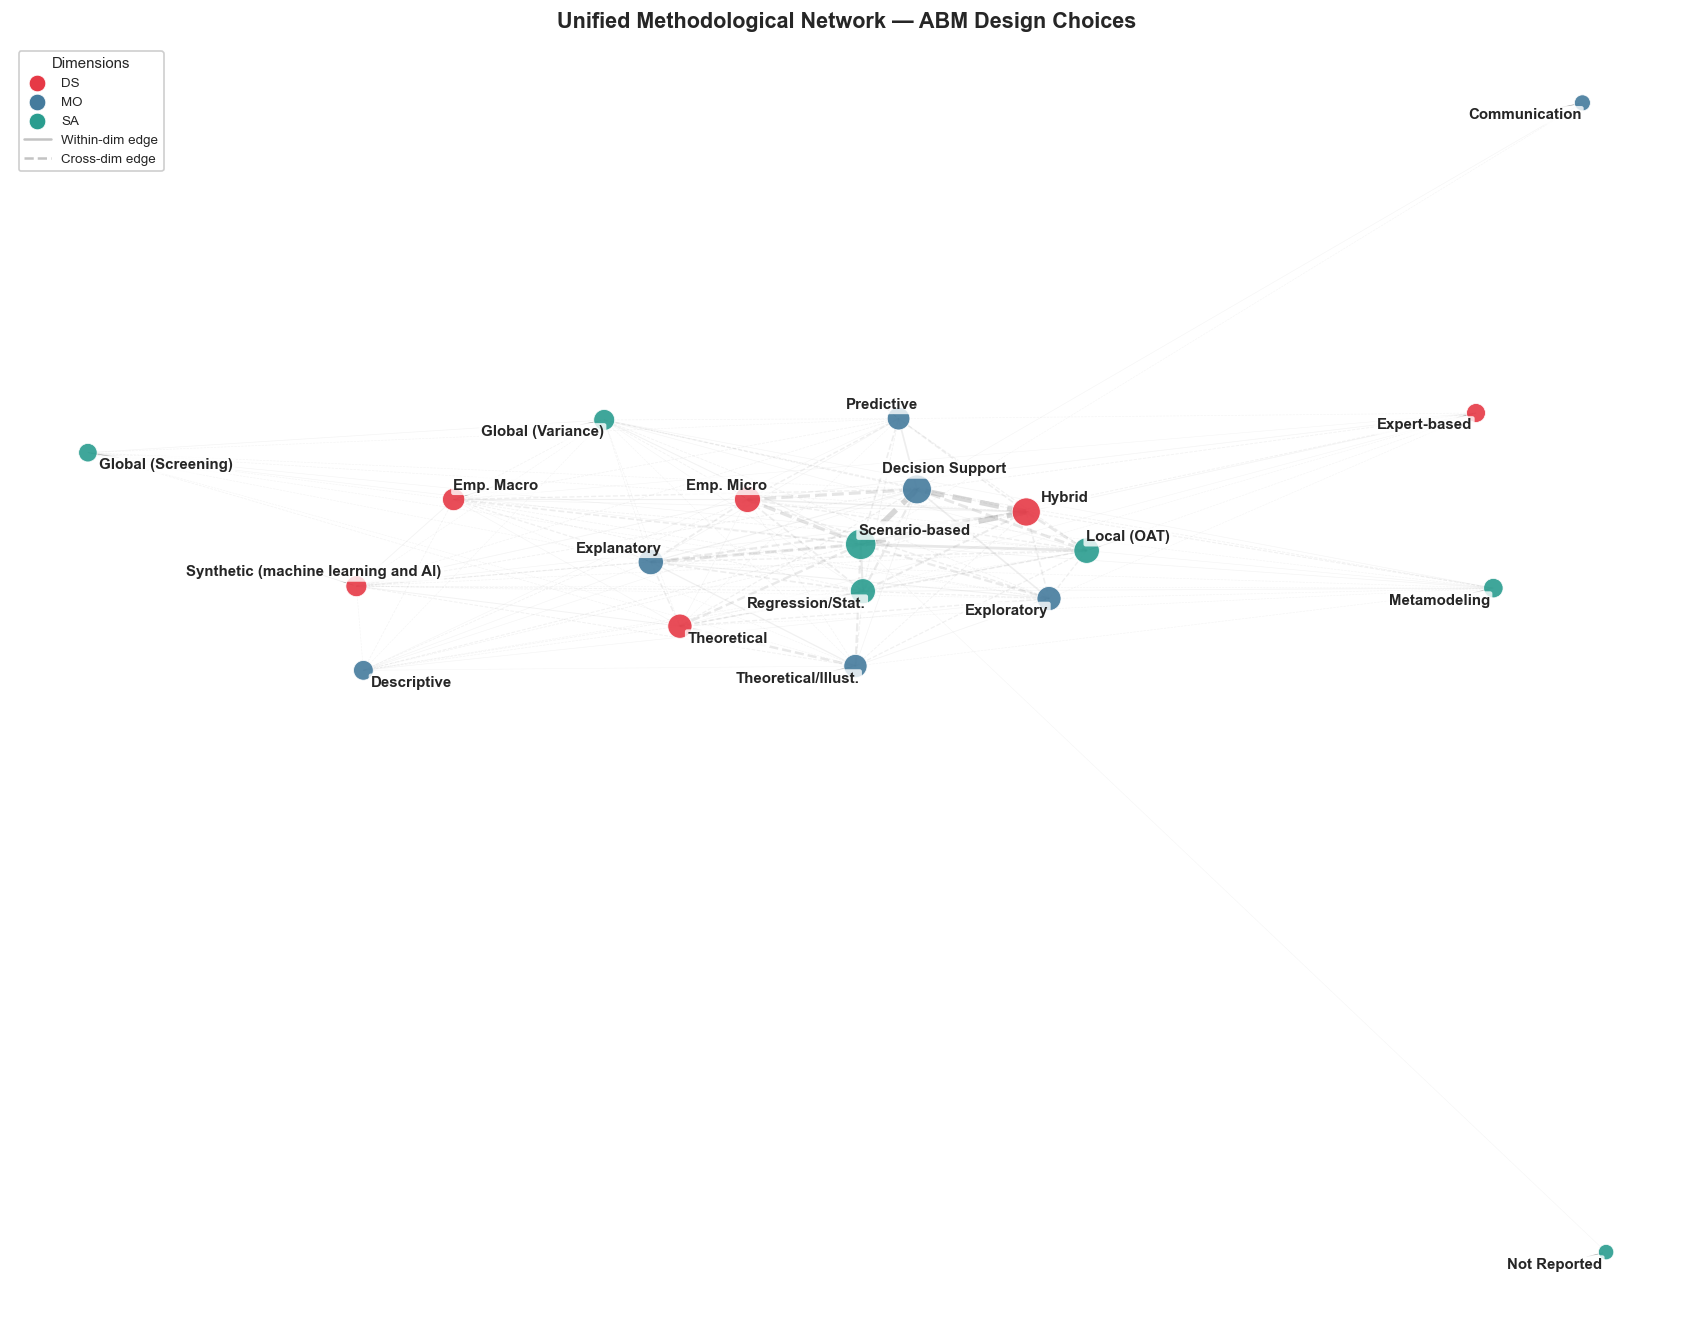

In [15]:
fig_net, ax_net = plot_unified_network(
    G_unified, unified_metrics,
    title="Unified Methodological Network — ABM Design Choices",
    figsize=(14, 11),
    node_scale=40,
    edge_alpha=0.25,
    font_size=9,
    layout_seed=42,
    save_path=os.path.join(FIG_DIR, "unified_network.png"),
)
plt.show()

## 7. Methodological Profiles

### Theoretical Foundation

A **methodological profile** is the complete set of classifications assigned to a single
article across all three dimensions. For example, an article might have the profile:
*[Theoretical + Empirical macro, Exploratory, Scenario-based]*.

Counting the most frequent profiles reveals the **dominant archetypes** of ABM design
in social sciences — the typical ways researchers combine data sources, objectives, and
validation strategies. Rare profiles may indicate innovative or underexplored combinations.

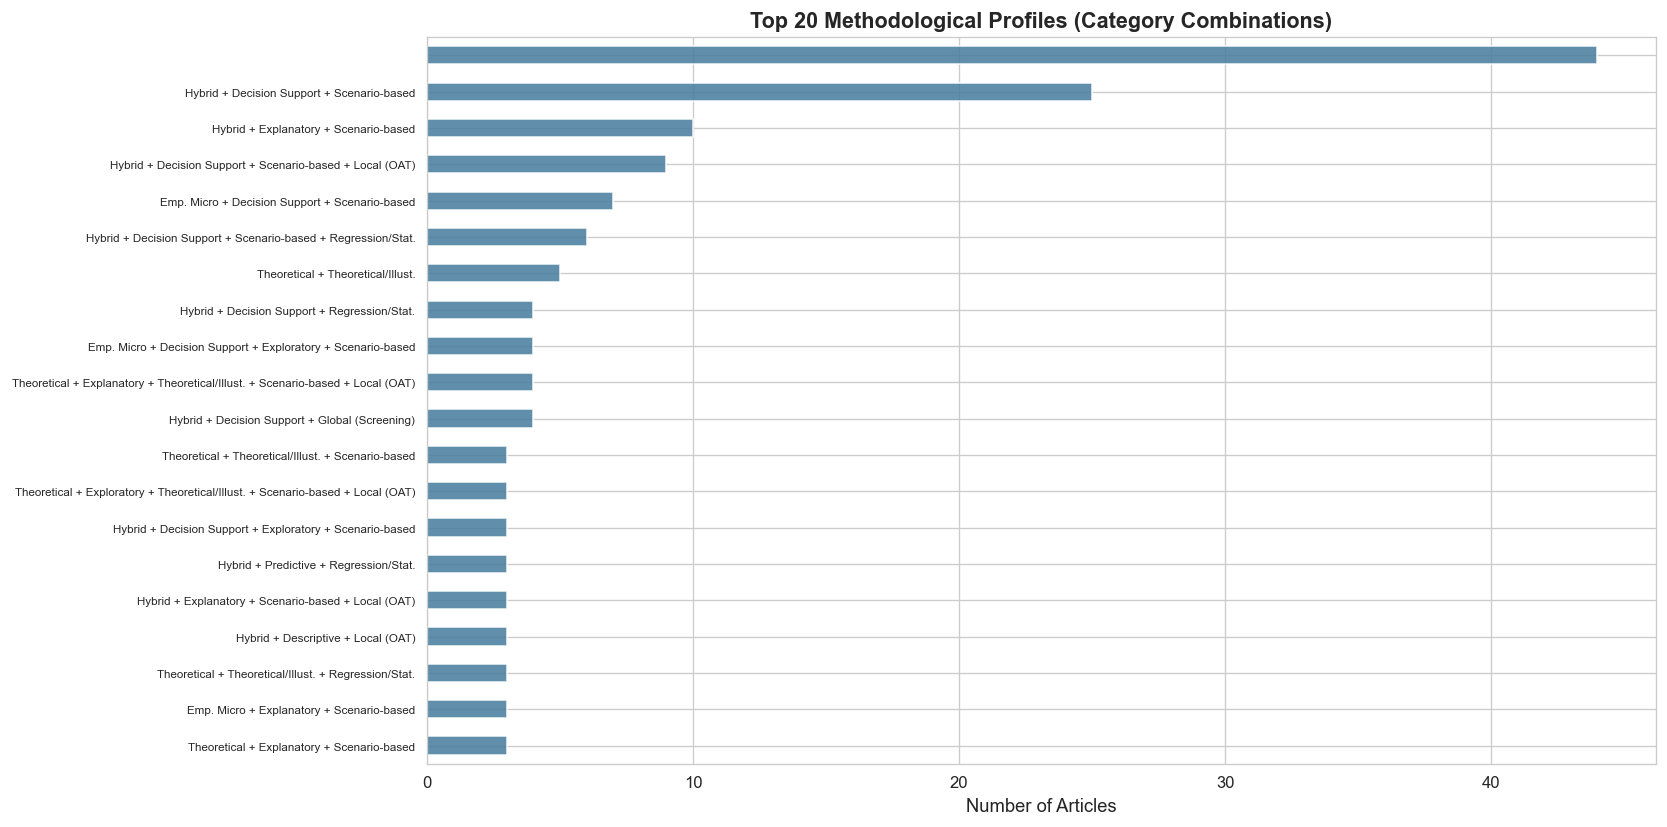

In [16]:
fig_prof = plot_stacked_combinations(
    df, parsed,
    figsize=(14, 7),
    save_path=os.path.join(FIG_DIR, "methodological_profiles.png"),
)
plt.show()

## 8. Temporal Trends

### Theoretical Foundation

Analyzing how the distribution of methodological choices evolves over time reveals
whether the field is moving towards more rigorous practices. For instance:
- Is the proportion of articles reporting **no sensitivity analysis** declining over time?
- Are **empirical data sources** becoming more common as more micro-data becomes available?
- Is there a trend towards **global sensitivity analysis** methods?

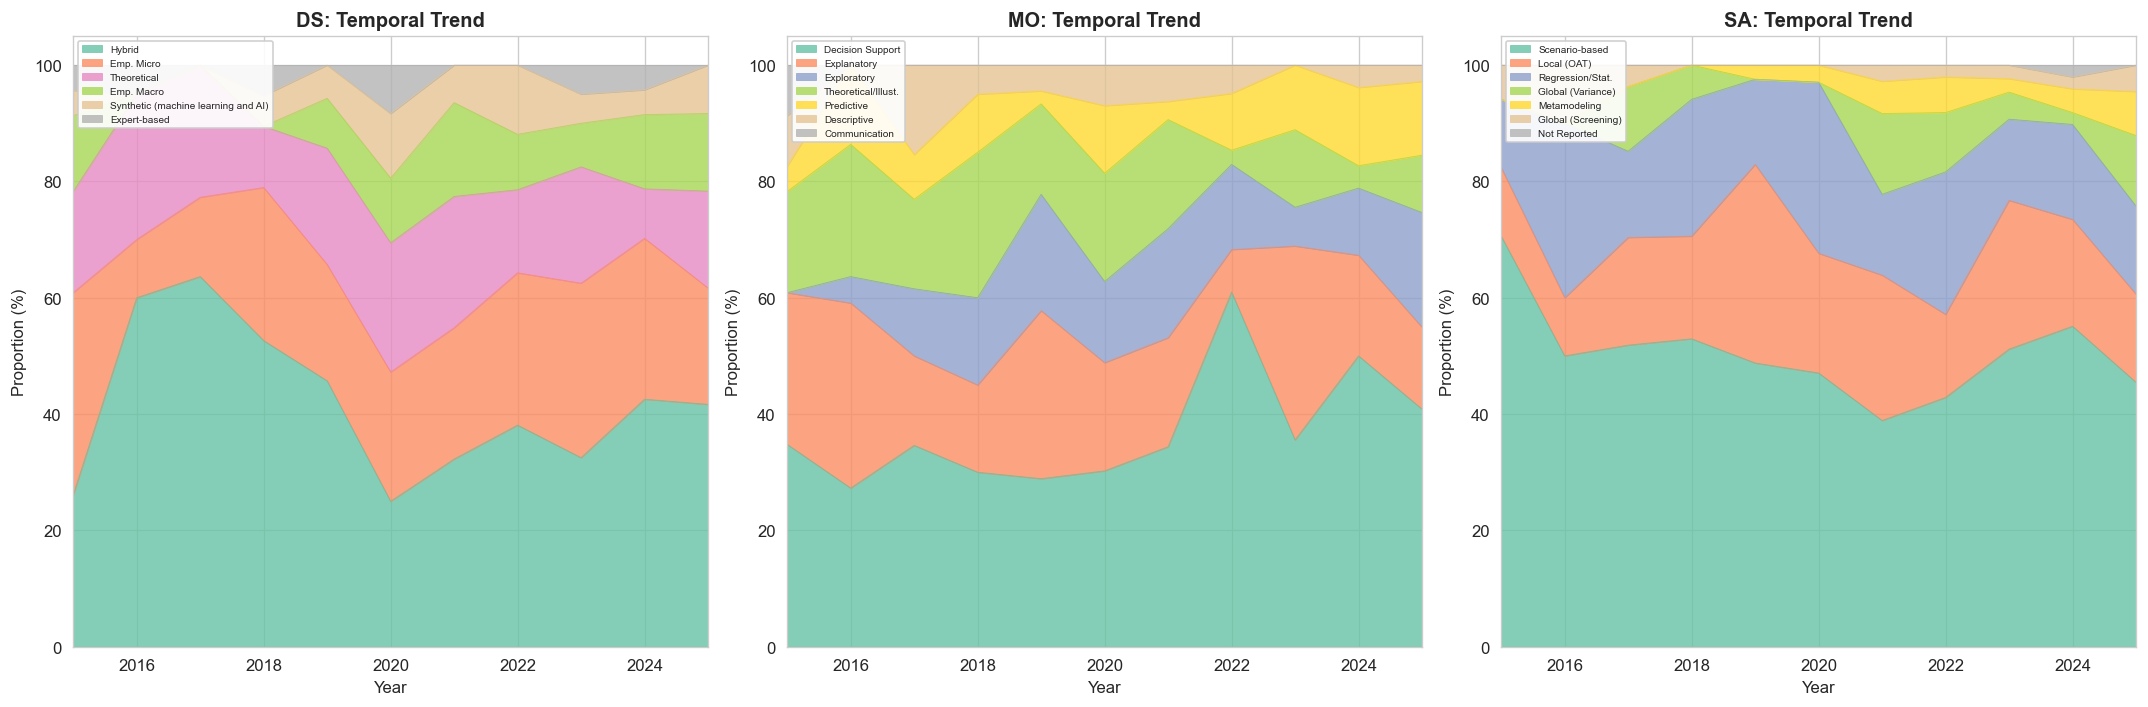

In [17]:
# Temporal trend for each dimension
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="white")

for ax, col in zip(axes, COLUMNS):
    dim = DIM_SHORT[col]
    # Build year × category matrix
    years = sorted(df["Publication Year"].dropna().astype(str).str[:4].unique().astype(int))
    cats = freq_dict[col].index.tolist()

    data = {}
    for year in years:
        mask = df["Publication Year"] == year
        year_parsed = parsed[col][mask]
        year_freq = get_frequency(year_parsed)
        for cat in cats:
            data.setdefault(SHORT_LABELS.get(cat, cat), []).append(
                year_freq.get(cat, 0)
            )

    year_df = pd.DataFrame(data, index=years)

    # Normalize to proportions per year
    year_pct = year_df.div(year_df.sum(axis=1), axis=0) * 100

    # Stacked area
    palette = DIM_COLORS.get(col, "#457B9D")
    colors = plt.cm.Set2(np.linspace(0, 1, len(cats)))
    year_pct.plot.area(ax=ax, stacked=True, alpha=0.8, color=colors, linewidth=0.5)
    ax.set_title(f"{dim}: Temporal Trend", fontsize=12, fontweight="bold")
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Proportion (%)", fontsize=10)
    ax.legend(fontsize=6, loc="upper left", framealpha=0.9)
    ax.set_xlim(years[0], years[-1])

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "temporal_trends.png"), dpi=300, bbox_inches="tight")
plt.show()

## 9. Export Results

All analysis outputs are exported for reproducibility and further exploration.

In [18]:
# --- 9.1 Unified network metrics ---
unified_metrics.to_csv(os.path.join(FIG_DIR, "unified_node_metrics.csv"))

# --- 9.2 Global metrics ---
pd.DataFrame([unified_global]).T.rename(columns={0: "value"}).to_csv(
    os.path.join(FIG_DIR, "unified_global_metrics.csv")
)

# --- 9.3 Within-dimension metrics ---
for col in COLUMNS:
    dim = DIM_SHORT[col]
    if col in within_metrics:
        within_metrics[col].to_csv(os.path.join(FIG_DIR, f"within_metrics_{dim}.csv"))

# --- 9.4 Cross-dimension co-occurrence matrices ---
for i, col_a in enumerate(COLUMNS):
    for col_b in COLUMNS[i+1:]:
        edges = build_cross_column_edges(None, col_a, col_b, parsed[col_a], parsed[col_b])
        dim_a = DIM_SHORT[col_a]
        dim_b = DIM_SHORT[col_b]
        edges.to_csv(os.path.join(FIG_DIR, f"cross_edges_{dim_a}_x_{dim_b}.csv"), index=False)

# --- 9.5 GEXF for Gephi ---
nx.write_gexf(G_unified, os.path.join(FIG_DIR, "unified_methodological_network.gexf"))

print("All outputs exported to:", FIG_DIR)
import os as _os
for f in sorted(_os.listdir(FIG_DIR)):
    print(f"  - {f}")

All outputs exported to: c:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\notebooks\figures_meth
  - category_frequencies.png
  - cross_edges_DS_x_MO.csv
  - cross_edges_DS_x_SA.csv
  - cross_edges_MO_x_SA.csv
  - heatmap_DS_x_MO.png
  - heatmap_DS_x_SA.png
  - heatmap_MO_x_SA.png
  - methodological_profiles.png
  - temporal_trends.png
  - unified_centrality.png
  - unified_global_metrics.csv
  - unified_methodological_network.gexf
  - unified_network.png
  - unified_node_metrics.csv
  - within_metrics_DS.csv
  - within_metrics_MO.csv
  - within_metrics_SA.csv
  - within_network_DS.png
  - within_network_MO.png
  - within_network_SA.png


## 10. Summary Table for Manuscript

Consolidated statistics for the results section of the scoping review.

In [19]:
summary = {
    "Total articles": len(df),
}

for col in COLUMNS:
    dim = DIM_SHORT[col]
    n_filled = df[col].notna().sum()
    n_unique = freq_dict[col].shape[0]
    n_multi = (parsed[col].apply(len) > 1).sum()
    summary[f"{dim}: articles classified"] = n_filled
    summary[f"{dim}: unique categories"] = n_unique
    summary[f"{dim}: multi-label articles"] = n_multi

summary["Unified network: nodes"] = G_unified.number_of_nodes()
summary["Unified network: edges"] = G_unified.number_of_edges()
summary["Unified network: density"] = f"{nx.density(G_unified):.4f}"

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
summary_df.index.name = "Metric"
summary_df

,Value
Metric,
Total articles,348
DS: articles classified,304
DS: unique categories,6
DS: multi-label articles,62
MO: articles classified,304
MO: unique categories,7
MO: multi-label articles,115
SA: articles classified,283
SA: unique categories,7


---

**End of Notebook 02 — Methodological Classification Network Analysis**

### Outputs generated:
| File | Description |
|------|-------------|
| `figures_meth/unified_network.png` | Main unified network visualization |
| `figures_meth/unified_methodological_network.gexf` | GEXF file for Gephi |
| `figures_meth/unified_node_metrics.csv` | Centrality metrics for all categories |
| `figures_meth/unified_centrality.png` | Top-12 centrality bar charts |
| `figures_meth/category_frequencies.png` | Category frequency distributions |
| `figures_meth/heatmap_DS_x_MO.png` | Data Source × Model Objective heatmap |
| `figures_meth/heatmap_DS_x_SA.png` | Data Source × Sensitivity Analysis heatmap |
| `figures_meth/heatmap_MO_x_SA.png` | Model Objective × Sensitivity Analysis heatmap |
| `figures_meth/within_network_DS.png` | Within-dimension network: Data Source |
| `figures_meth/within_network_MO.png` | Within-dimension network: Model Objective |
| `figures_meth/within_network_SA.png` | Within-dimension network: Sensitivity Analysis |
| `figures_meth/methodological_profiles.png` | Top 20 methodological profile combinations |
| `figures_meth/temporal_trends.png` | Temporal evolution of each dimension |